# Airflow — one verdict per breath

Visual inspection of the cycle-rejection method. Two views, both restricted to the **analysed window** (the union of the trials' `response_range_sec`, ~37 % of the recording).

Sessions are labelled **A / B** in sorted key order. Set `REVEAL_SESSION_LABELS = True` to show `eve`/`mor` — off by default so the judgement cannot be steered by condition.

Method reference: `Airflow/_scratch/METHOD.md`.

In [23]:
import os, sys, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython import get_ipython

sys.path.insert(0, '/Users/yotameviatar/startle-1')
from Airflow import airflow_config as config
from Airflow import airflow_glm as glm
from Airflow import airflow_qc

get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams.update({'figure.dpi': 110})

SUBJECT = 'RP06'
METRIC  = 'RA'
PAGE_SEC = 60.0
REVEAL_SESSION_LABELS = False
Z_YLIM_FALLBACK = 5.0   # used only if a session has no accepted breath in the window

cache_path = os.path.join(config.OUTPUT_DIR, "_cache", "airflow_cache.pkl")
with open(cache_path, "rb") as f:
    sessions_cache = pickle.load(f)["sessions"]

print(f"{len(sessions_cache)} subjects | CYCLE_RP_MAX={config.CYCLE_RP_MAX} "
      f"LOSTLOCK_MIN_PEAKS={config.CYCLE_LOSTLOCK_MIN_PEAKS} "
      f"TRIAL_MIN_VALID_FRAC={config.TRIAL_MIN_VALID_FRAC} "
      f"CONDITION_FIELD={config.GLM_CONDITION_FIELD!r}")
_excl = list(getattr(config, "SUBJECTS_EXCLUDE", []))
_subj_excl = [e for e in _excl if "/" not in e]
_sess_excl = [e for e in _excl if "/" in e]
print(f"excluded subjects : {_subj_excl}")
print(f"excluded sessions : {_sess_excl}")
print(f"available subjects: {sorted(s for s in sessions_cache if s not in _subj_excl)}")
print(f"\n{SUBJECT} sessions: {sorted(sessions_cache[SUBJECT])}")
if SUBJECT in _subj_excl:
    print(f"  !! {SUBJECT} is in SUBJECTS_EXCLUDE — it is NOT in the scored cohort")
for _sk in sorted(sessions_cache[SUBJECT]):
    if f"{SUBJECT}/{_sk}" in _sess_excl:
        print(f"  !! {SUBJECT}/{_sk} is in SUBJECTS_EXCLUDE — not in the scored cohort")
    if f"{SUBJECT}/{_sk}" in getattr(config, "MANUAL_BAD_SPANS", {}):
        print(f"  !  {SUBJECT}/{_sk} has MANUAL_BAD_SPANS "
              f"{config.MANUAL_BAD_SPANS[f'{SUBJECT}/{_sk}']} removed from its cycles")


24 subjects | CYCLE_RP_MAX=7.0 LOSTLOCK_MIN_PEAKS=3 TRIAL_MIN_VALID_FRAC=0.6 CONDITION_FIELD='none'
excluded subjects : ['DA01', 'NB03', 'YL26']
excluded sessions : ['ES29/eve', 'EV15/eve', 'LG07/mor', 'MG14/mor', 'MS13/eve']
available subjects: ['AB22', 'AG05', 'AH19', 'AK12', 'AS09', 'EE10', 'ER23', 'ES29', 'EV15', 'LB17', 'LG07', 'LO21', 'MG14', 'MH20', 'ML28', 'MS13', 'MS18', 'OM16', 'RP06', 'SH25', 'YR08']

RP06 sessions: ['eve', 'mor']


## Session state

One call per session, memoised. Mirrors `run_glm_scoring` Pass A exactly: filter → detect → peak count → classify → neighbour rules → admit → series.

In [24]:
GATE_COLORS = {
    "unmeasurable":     "#555555",
    "extreme":          "#A81D3C",
    "rate_implausible": "#C77D0A",
    "no_inspiration":   "#6B4C9A",
    "lost_lock":        "#1F618D",
    "recovery":         "#D9A0AE",
    "gap_fill":         "#8A9793",
}

_qc_memo = {}


def compute_session_qc(subj, sess_key):
    key = (subj, sess_key)
    if key in _qc_memo:
        return _qc_memo[key]
    sess = sessions_cache[subj][sess_key]
    signal_raw = np.asarray(sess["signal_raw"], dtype=float)
    native_sfreq = float(sess["sfreq"])
    trials_meta = sess["trials_meta"]

    raw_z, sfreq = glm.phase1_filter_downsample(
        signal_raw, native_sfreq, target_sfreq=config.GLM_TARGET_SFREQ,
        bp_low=config.GLM_CYCLE_BANDPASS[0], bp_high=config.GLM_CYCLE_BANDPASS[1],
        zscore=config.GLM_ZSCORE_RAW, despike=config.GLM_DESPIKE_ENABLED)

    cycles = glm.detect_cycles(
        raw_z, sfreq, signal_raw, native_sfreq,
        median_win_sec=config.GLM_MEDIAN_WIN_SEC,
        refractory_sec=config.GLM_REFRACTORY_SEC)

    pk, _ = glm._nk2_peak_trough_times(raw_z, sfreq, config)
    glm.attach_cycle_features(cycles, signal_raw, native_sfreq, pk)

    rejected, reason, rep = airflow_qc.classify_cycles(cycles, config)
    rejected, reason = airflow_qc.apply_neighbour_rules(rejected, reason, config)
    report = airflow_qc._cycle_report(cycles, rejected, reason, rep["abstained"],
                                      rep["n_ref_cycles"], rep["median_RA"], rep["cut_RA"])

    manual = [(float(a), float(b)) for a, b in
              getattr(config, "MANUAL_BAD_SPANS", {}).get(f"{subj}/{sess_key}", [])]
    if manual:
        keep = [not any(c["onset_time"] < b and c["assign_time"] > a for a, b in manual)
                for c in cycles]
        cycles = [c for c, k in zip(cycles, keep) if k]
        rejected = np.array([r for r, k in zip(rejected, keep) if k], dtype=bool)
        reason = [r for r, k in zip(reason, keep) if k]
    missing_spans = list(manual)

    n_samples = len(raw_z)
    d105 = [m["d105_time"] for m in trials_meta if m.get("d105_time") is not None]
    codes = [m["code_time"] for m in trials_meta if m.get("code_time") is not None]
    if d105 and codes:
        crop_end = max(codes) + config.GLM_POST_CODE_SEC
        n_samples = min(n_samples, int(np.ceil(max(crop_end, 0.0) * sfreq)))
        crop_start = min(d105) - config.GLM_PRE_FIXATION_SEC
        if crop_start > 0:
            missing_spans = missing_spans + [(0.0, crop_start)]

    admission = glm.admit_trials(trials_meta, cycles, rejected, config)
    if config.GLM_ESTIMATION == "pooled_session":
        missing_spans += [a["span"] for a in admission.values() if not a["admitted"]]

    series, times_full = glm.build_continuous_series(
        cycles, n_samples, sfreq, hp=config.GLM_FINAL_HP, lp=config.GLM_FINAL_LP,
        missing_spans=missing_spans, rejected=rejected)

    spans = [m["response_range_sec"] for m in trials_meta]
    w0, w1 = min(a for a, b in spans), max(b for a, b in spans)

    out = dict(signal_raw=signal_raw, native_sfreq=native_sfreq, raw_z=raw_z, sfreq=sfreq,
               cycles=cycles, rejected=rejected, reason=reason, report=report,
               series=series, times_full=times_full, trials_meta=trials_meta,
               admission=admission, win0=w0, win1=w1,
               rej_spans=glm.rejected_cycle_spans(cycles, rejected) if len(cycles) else [])
    _qc_memo[key] = out
    return out


def sess_label(i, sess_key):
    return sess_key if REVEAL_SESSION_LABELS else f"Session {'AB'[i]}"


def env_decimate(t, y, n_out=3000):
    n = len(y)
    if n <= 2 * n_out:
        return t, y
    step = int(np.ceil(n / n_out))
    m = (n // step) * step
    yy = np.asarray(y[:m], float).reshape(-1, step)
    tt = np.asarray(t[:m], float).reshape(-1, step)
    with np.errstate(invalid="ignore"):
        lo = np.nanmin(yy, axis=1)
        hi = np.nanmax(yy, axis=1)
    allnan = np.all(~np.isfinite(yy), axis=1)
    lo[allnan] = np.nan
    hi[allnan] = np.nan
    t_out = np.repeat(tt[:, 0], 2)
    y_out = np.empty(t_out.size)
    y_out[0::2] = lo
    y_out[1::2] = hi
    return t_out, y_out


def gate_summary(S):
    gc = S["report"]["gate_counts"]
    txt = ", ".join(f"{g} {n}" for g, n in sorted(gc.items())) or "none rejected"
    ab = S["report"]["abstained"]
    if ab:
        txt += f"   ABSTAINED: {', '.join(ab)}"
    return txt


def window_cycles(S):
    w0, w1 = S["win0"], S["win1"]
    out = []
    cid = 0
    for c, bad, rsn in zip(S["cycles"], S["rejected"], S["reason"]):
        if c["onset_time"] < w1 and c["assign_time"] > w0:
            cid += 1
            out.append((cid, c, bool(bad), rsn))
    return out


def accepted_z_limit(S, pad=1.05):
    """Y-limit for the raw_z panel: the largest |z| reached by an ACCEPTED breath
    inside the analysed window. Scale is then a property of this session's own
    valid breathing, not a fixed constant."""
    t = np.arange(len(S["raw_z"])) / S["sfreq"]
    keep = np.zeros(len(t), dtype=bool)
    for _, c, bad, _ in window_cycles(S):
        if bad:
            continue
        keep |= (t >= c["onset_time"]) & (t <= c["assign_time"])
    if not keep.any():
        return Z_YLIM_FALLBACK
    v = np.nanmax(np.abs(S["raw_z"][keep]))
    return float(v) * pad if np.isfinite(v) and v > 0 else Z_YLIM_FALLBACK


## View 1 — main view

Three layers, both sessions side by side.

1. `signal_raw` @ 25 Hz, rejected breath spans shaded
2. `raw_z` @ 10 Hz with detected onsets
3. `series[METRIC]` with its NaN holes

Vertical lines are trial picture onsets: green admitted, red rejected.

In [25]:
def main_view(subj, metric=METRIC):
    keys = sorted(sessions_cache[subj].keys())
    fig, axes = plt.subplots(3, len(keys), figsize=(9.0 * len(keys), 9.5),
                             squeeze=False, gridspec_kw=dict(hspace=0.30, wspace=0.12))
    for j, sk in enumerate(keys):
        S = compute_session_qc(subj, sk)
        w0, w1 = S["win0"], S["win1"]
        ax0, ax1, ax2 = axes[0, j], axes[1, j], axes[2, j]

        t_nat = np.arange(len(S["signal_raw"])) / S["native_sfreq"]
        m = (t_nat >= w0) & (t_nat <= w1)
        td, yd = env_decimate(t_nat[m], S["signal_raw"][m])
        ax0.plot(td, yd, color="#141C1A", lw=0.5)
        for a, b in S["rej_spans"]:
            if b > w0 and a < w1:
                ax0.axvspan(max(a, w0), min(b, w1), color="#A81D3C", alpha=0.16, lw=0)
        n_cyc = len(window_cycles(S))
        n_rej = sum(1 for _, _, bad, _ in window_cycles(S) if bad)
        ax0.set_title(f"{sess_label(j, sk)} — signal_raw @ {S['native_sfreq']:.0f} Hz  "
                      f"({n_cyc - n_rej}/{n_cyc} breaths kept in window; shaded = rejected)\n"
                      f"{gate_summary(S)}", fontsize=8.5, loc="left")
        ax0.set_ylabel("raw units")

        t_z = np.arange(len(S["raw_z"])) / S["sfreq"]
        mz = (t_z >= w0) & (t_z <= w1)
        td, yd = env_decimate(t_z[mz], S["raw_z"][mz])
        ax1.plot(td, yd, color="#1F618D", lw=0.5)
        ons = [c["onset_time"] for _, c, _, _ in window_cycles(S)]
        zlim = accepted_z_limit(S)
        ax1.plot(ons, np.full(len(ons), -zlim * 0.92), "|", color="#0E7C6B", ms=7, mew=0.8)
        zw = S["raw_z"][mz]
        n_clip = int(np.sum(np.abs(zw) > zlim))
        zmax = float(np.nanmax(np.abs(zw))) if zw.size else np.nan
        ax1.set_ylim(-zlim, zlim)
        ax1.axhline(zlim, color="#8A9793", lw=0.5, ls=":")
        ax1.axhline(-zlim, color="#8A9793", lw=0.5, ls=":")
        clip_note = (f", {n_clip} samples clipped, peak {zmax:.1f}" if n_clip else "")
        ax1.set_title(f"raw_z @ {S['sfreq']:.0f} Hz — bandpass "
                      f"{config.GLM_CYCLE_BANDPASS[0]}–{config.GLM_CYCLE_BANDPASS[1]} Hz, robust z\n"
                      f"{len(ons)} onsets; y-scale ±{zlim:.1f} = max |z| of accepted "
                      f"breaths{clip_note}", fontsize=8.5, loc="left")
        ax1.set_ylabel("z")

        t_s = S["times_full"]
        ms = (t_s >= w0) & (t_s <= w1)
        y = np.asarray(S["series"][metric], float)[ms]
        ax2.plot(t_s[ms], y, color="#117A65", lw=0.8)
        nan_frac = float(np.mean(~np.isfinite(y))) if y.size else np.nan
        ax2.set_title(f"series['{metric}'] — knots interpolated, causal filter, holes NaN'd  "
                      f"({100*nan_frac:.1f}% NaN in window)", fontsize=8.5, loc="left")
        ax2.set_ylabel(metric)
        ax2.set_xlabel("time (s)")

        for meta in S["trials_meta"]:
            adm = S["admission"].get(meta["trial_index"], {})
            col = "#0E7C6B" if adm.get("admitted", True) else "#A81D3C"
            for ax in (ax0, ax1, ax2):
                ax.axvline(meta["code_time"], color=col, lw=0.7, alpha=0.6, zorder=4)

        for ax in (ax0, ax1, ax2):
            ax.set_xlim(w0, w1)

    handles = [mpatches.Patch(color="#0E7C6B", label="trial admitted"),
               mpatches.Patch(color="#A81D3C", label="trial rejected / breath rejected")]
    fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=8, frameon=False)
    fig.suptitle(f"{subj} — analysed window only "
                 f"({config.GLM_ESTIMATION}, one β per session)", fontsize=11, y=0.995)
    return fig


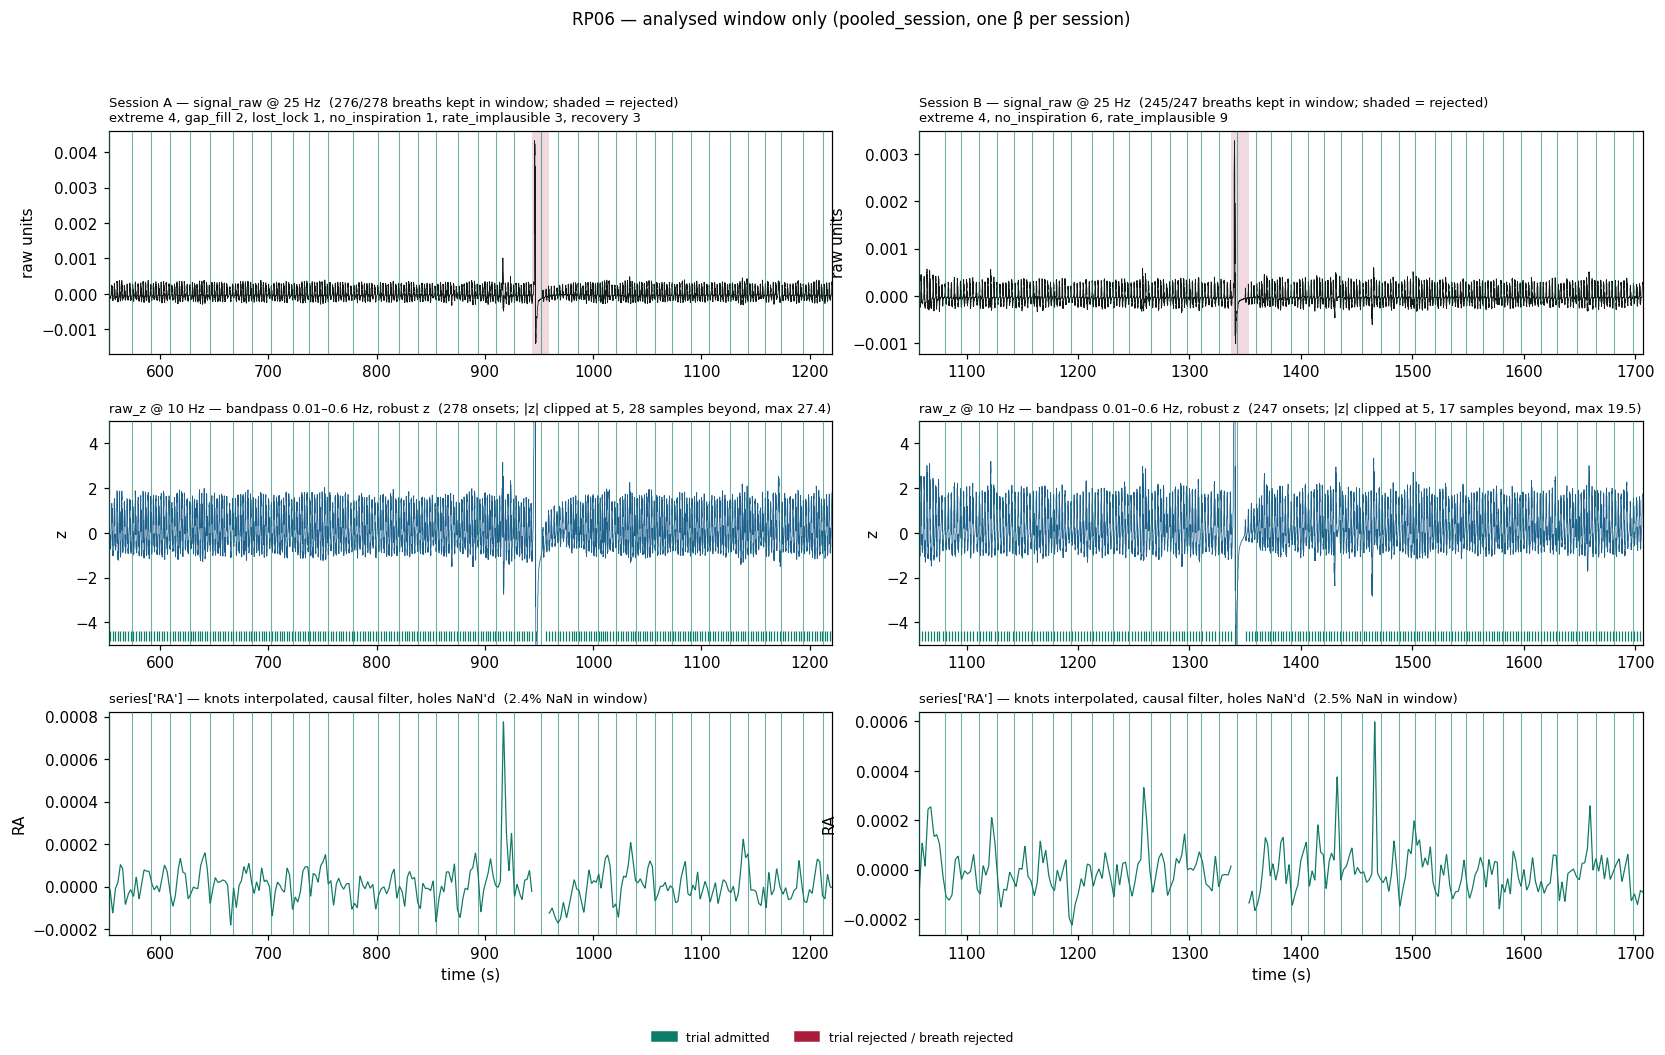

In [26]:
fig = main_view(SUBJECT)
plt.show()

## View 2 — tagging view

Paged 60 s rows over `signal_raw` across the analysed window. Every breath is boxed and coloured by its verdict; the gate name is printed under each rejected breath. Cycle ids are 1-based within the analysed window, shown for every rejected breath and every 10th kept one.

`max_pages=None` renders the whole session.

In [27]:
def tagging_view(subj, max_pages=None):
    keys = sorted(sessions_cache[subj].keys())
    states = [compute_session_qc(subj, sk) for sk in keys]
    pages = [int(np.ceil((S["win1"] - S["win0"]) / PAGE_SEC)) for S in states]
    n_rows = max(pages) if max_pages is None else min(max(pages), max_pages)

    fig, axes = plt.subplots(n_rows, len(keys), figsize=(10.5 * len(keys), 1.9 * n_rows),
                             squeeze=False, gridspec_kw=dict(hspace=0.55, wspace=0.08))
    for j, (sk, S) in enumerate(zip(keys, states)):
        t_nat = np.arange(len(S["signal_raw"])) / S["native_sfreq"]
        wc = window_cycles(S)
        for r in range(n_rows):
            ax = axes[r, j]
            p0 = S["win0"] + r * PAGE_SEC
            p1 = min(p0 + PAGE_SEC, S["win1"])
            if p0 >= S["win1"]:
                ax.axis("off")
                continue
            m = (t_nat >= p0) & (t_nat <= p1)
            ax.plot(t_nat[m], S["signal_raw"][m], color="#141C1A", lw=0.6)
            lo, hi = (np.nanmin(S["signal_raw"][m]), np.nanmax(S["signal_raw"][m])) \
                if m.any() else (0.0, 1.0)
            pad = 0.18 * (hi - lo if hi > lo else 1.0)
            for cid, c, bad, rsn in wc:
                if c["assign_time"] <= p0 or c["onset_time"] >= p1:
                    continue
                a, b = c["onset_time"], c["assign_time"]
                col = GATE_COLORS.get(rsn, "#A81D3C") if bad else "#0E7C6B"
                ax.add_patch(mpatches.Rectangle(
                    (a, lo - pad * 0.4), b - a, (hi - lo) + pad * 0.8,
                    facecolor=col, alpha=0.16 if bad else 0.05,
                    edgecolor=col, lw=0.7, zorder=1))
                if bad or cid % 10 == 0:
                    ax.text(a + (b - a) / 2, hi + pad * 0.55, str(cid),
                            ha="center", va="bottom", fontsize=5.5,
                            color=col if bad else "#8A9793")
                if bad:
                    ax.text(a + (b - a) / 2, lo - pad * 0.5, rsn,
                            ha="center", va="top", fontsize=5.5, color=col)
            ax.set_xlim(p0, p1)
            ax.set_ylim(lo - pad, hi + pad)
            ax.set_yticks([])
            ax.tick_params(labelsize=6)
            if r == 0:
                ax.set_title(f"{sess_label(j, sk)} — tagging view, "
                             f"{len(wc)} breaths in analysed window", fontsize=9, loc="left")
            ax.text(0.002, 0.97, f"{p0:.0f}–{p1:.0f} s", transform=ax.transAxes,
                    fontsize=6, va="top", color="#8A9793")

    used = sorted({r for _, _, bad, r in
                   [x for S in states for x in window_cycles(S)] if bad})
    handles = [mpatches.Patch(facecolor="#0E7C6B", alpha=0.35, edgecolor="#0E7C6B", label="kept")]
    handles += [mpatches.Patch(facecolor=GATE_COLORS.get(g, "#A81D3C"), alpha=0.45,
                               edgecolor=GATE_COLORS.get(g, "#A81D3C"), label=g) for g in used]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 7),
               fontsize=8, frameon=False)
    fig.suptitle(f"{subj} — one verdict per breath", fontsize=11, y=0.999)
    return fig


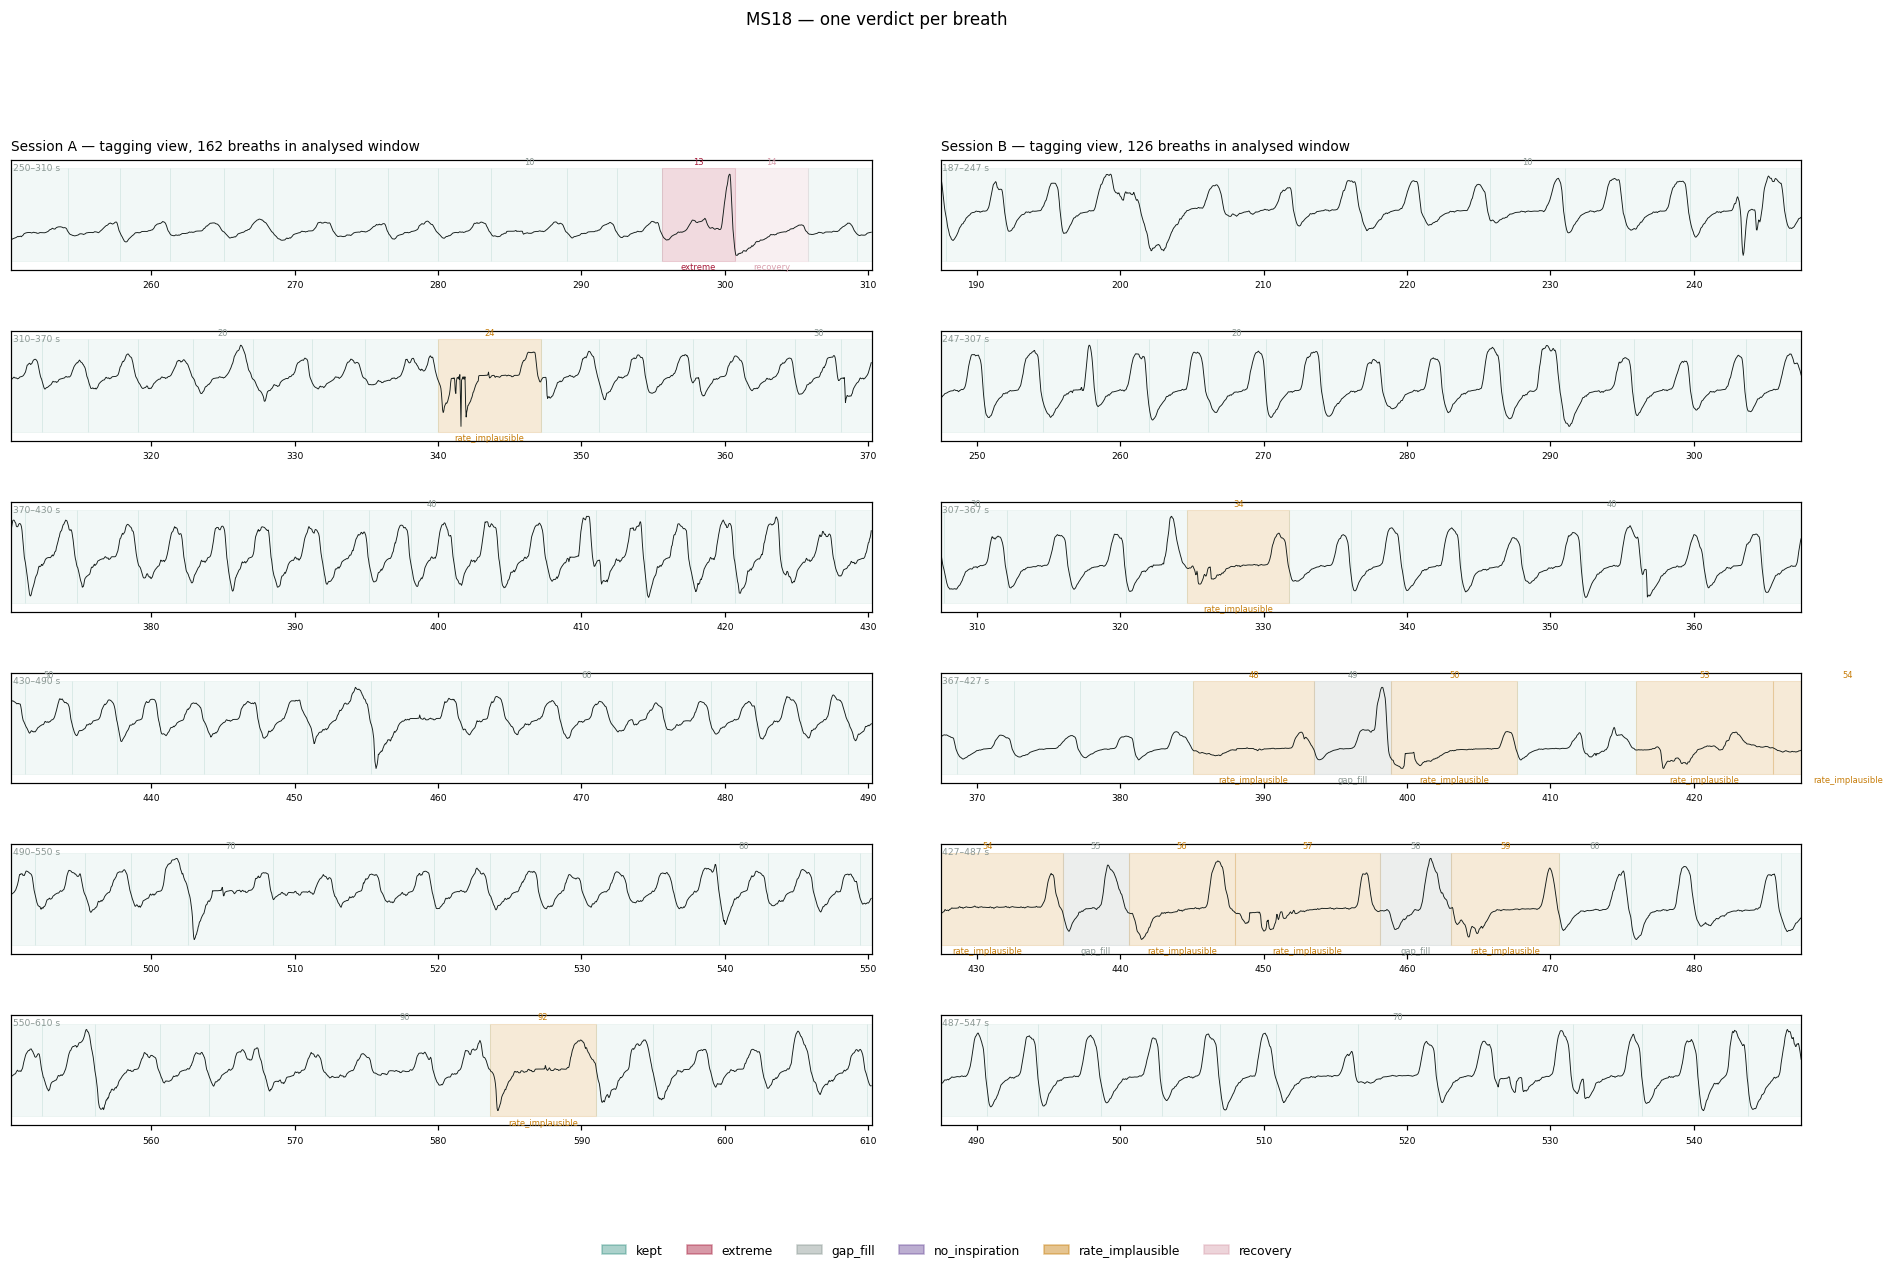

In [22]:
fig = tagging_view(SUBJECT, max_pages=6)
plt.show()